# 5. A strongly driven two-level atom in a cavity: bare versus dressed lines — Fig. 7 (Sec. V.B)

$\gamma=1$, $\kappa=\gamma/2$, $\Delta_a=0$. *Bare split*: the drive is a vertex; the drive vertices form a geometric ladder with ratio $-\Omega^2/2D$, so the series diverges beyond $\Omega=\gamma/\sqrt2$. *Dressed split*: the driven atom sits inside $\mathcal L_0$ and only the atom–cavity exchange is perturbative; each of the three dressed eigenoperators produces one Mollow component, one line per component.

(a) cavity photon number versus cavity detuning at $\Omega=5\gamma$, $g=\gamma/5$; (b) photon number at $\Delta_c=0$ versus $\Omega$ for $g=\gamma/10$, relative to a classical dipole with the same rates.

**Part A** runs the calculation; **Part B** regenerates Fig. 7 with `make_figures.py emitter` (~15 s).

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_work | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A — the calculation

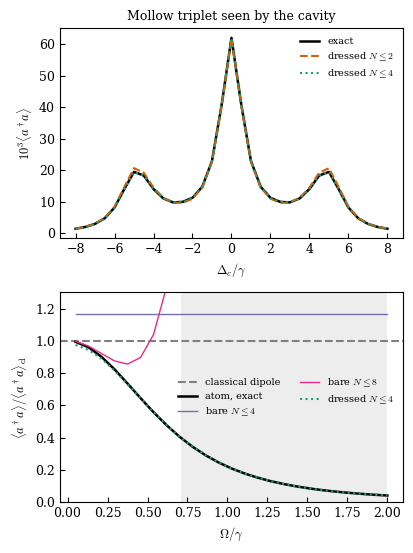

max relative error, dressed N<=4 (panel a): 0.0037   (paper: 0.4 %)


In [2]:
sm = np.array([[0,0],[1,0]],complex); sp_ = sm.conj().T
sz = np.diag([1.,-1.]).astype(complex); sx = sm+sp_; I2 = np.eye(2)
def atom_gen(Da,Om,gam):
    Ha = Da/2*sz + Om/2*sx
    La = lambda X: 1j*(Ha@X-X@Ha) + gam*(sp_@X@sm - 0.5*(sp_@sm@X + X@sp_@sm))     # adjoint generator: +i[H, .]
    return La, steady(Ha,[np.sqrt(gam)*sm])
def em_series(kap,Dc_,Da,Om,gam,g,N,O,dressed=True):
    z_ = kap/2+1j*Dc_; A_,Ad_ = cav(0,1,I2), cav(1,0,I2)
    Hx = scale(g, add(mul(Ad_,cav(0,0,sm)), mul(A_,cav(0,0,sp_))))
    if dressed: La,rho = atom_gen(Da,Om,gam); Hint = Hx
    else:       La,rho = atom_gen(Da,0.0,gam); Hint = add(Hx, cav(0,0,Om/2*sx))
    return Model(2,z_,La,rho,Hint,2).series(O,N)
def em_exact(kap,Dc_,Da,Om,gam,g,Nc_=8):
    A_=np.kron(destroy(Nc_),I2); Ad_=A_.conj().T; S=np.kron(np.eye(Nc_),sm)
    H=Dc_*Ad_@A_+np.kron(np.eye(Nc_),Da/2*sz+Om/2*sx)+g*(Ad_@S+A_@S.conj().T)
    return np.trace(Ad_@A_@steady(H,[np.sqrt(kap)*A_,np.sqrt(gam)*S])).real
gam_,kap_ = 1.0, 0.5
Dcs = np.linspace(-8,8,33 if FAST else 161)
ex_a=np.array([em_exact(kap_,D,0.0,5.0,gam_,0.2) for D in Dcs])
n2_a=np.array([np.sum(em_series(kap_,D,0.0,5.0,gam_,0.2,2,cav(1,1,I2))) for D in Dcs]).real
n4_a=np.array([np.sum(em_series(kap_,D,0.0,5.0,gam_,0.2,4,cav(1,1,I2))) for D in Dcs]).real
Oms=np.linspace(0.05,2.0,25 if FAST else 100); g_=0.1
def n_cl(O):
    M=np.array([[kap_/2,1j*g_],[1j*g_,gam_/2]]); av,_=np.linalg.solve(M,[0,-1j*O/2]); return abs(av)**2
ncl=np.array([n_cl(O) for O in Oms])
ex_b=np.array([em_exact(kap_,0.0,0.0,O,gam_,g_) for O in Oms])/ncl
nd4=np.array([np.sum(em_series(kap_,0.0,0.0,O,gam_,g_,4,cav(1,1,I2))) for O in Oms]).real/ncl
Nb=8 if FAST else 16
sb=np.array([np.cumsum(em_series(kap_,0.0,0.0,O,gam_,g_,Nb,cav(1,1,I2),dressed=False)).real for O in Oms])/ncl[:,None]
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(4.2,5.6))
ax1.plot(Dcs,1e3*ex_a,'k-',lw=1.8,label='exact'); ax1.plot(Dcs,1e3*n2_a,'--',color=COL[0],label='dressed $N\\leq2$')
ax1.plot(Dcs,1e3*n4_a,':',color=COL[1],lw=1.5,label='dressed $N\\leq4$')
ax1.set_xlabel(r'$\Delta_c/\gamma$'); ax1.set_ylabel(r'$10^3\langle a^\dagger a\rangle$'); ax1.legend(fontsize=7)
ax1.set_title('Mollow triplet seen by the cavity',fontsize=9)
ax2.axvspan(gam_/np.sqrt(2),2,color='0.93',lw=0); ax2.axhline(1,ls='--',color='0.5',label='classical dipole')
ax2.plot(Oms,ex_b,'k-',lw=1.8,label='atom, exact')
for c,N in zip(COL[2:],[4,Nb]): ax2.plot(Oms,sb[:,N],color=c,lw=1,label=f'bare $N\\leq{N}$')
ax2.plot(Oms,nd4,':',color=COL[1],lw=1.5,label='dressed $N\\leq4$')
ax2.set_ylim(0,1.3); ax2.set_xlabel(r'$\Omega/\gamma$'); ax2.set_ylabel(r'$\langle a^\dagger a\rangle/\langle a^\dagger a\rangle_{\rm cl}$')
ax2.legend(fontsize=7,ncol=2)
fig.tight_layout(); plt.show()
print(f"max relative error, dressed N<=4 (panel a): {np.max(np.abs(n4_a/ex_a-1)):.4f}   (paper: 0.4 %)")

## Part B — Fig. 7 of the paper

$ (cd code/engines; python3 make_figures.py emitter)   [6.8 s, exit 0]
  "g": 0.2
 }
}


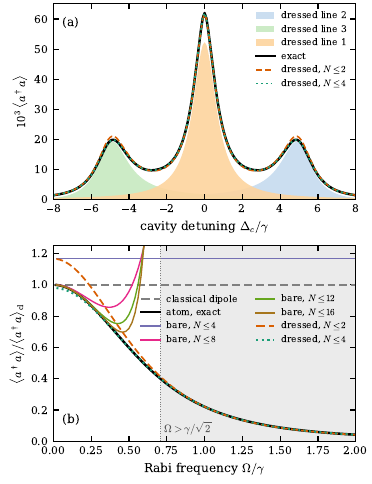

dressed eigenvalues of the driven atom (the three Mollow components): {'2': '-0.750-4.994i', '3': '-0.750+4.994i', '1': '-0.500-0.000i'}
(a) max relative error: dressed N<=2 6.1%, N<=4 0.37%   (paper: 0.4 % at fourth order)
(b) dressed expansion, max relative error over Omega: N<=2 16.6%, N<=4 2.0%; exact ratio at Omega=2gamma: 0.042


In [3]:
run("python3 make_figures.py emitter", "engines", timeout=1200)
paper_figure("engines/fig_emitter.pdf")
n = J("engines", "numbers.json")
print("dressed eigenvalues of the driven atom (the three Mollow components):", {k: f"{v[0]:.3f}{v[1]:+.3f}i" for k, v in n["emitter_lambdas"].items()})
print(f"(a) max relative error: dressed N<=2 {100*n['emitter_a_maxrel_err_N2']:.1f}%, N<=4 {100*n['emitter_a_maxrel_err_N4']:.2f}%   (paper: 0.4 % at fourth order)")
print(f"(b) dressed expansion, max relative error over Omega: N<=2 {100*n['emitter_b_dressed_maxrel_err']:.1f}%, N<=4 {100*n['emitter_b_dressed4_maxrel_err']:.1f}%; exact ratio at Omega=2gamma: {n['emitter_b_ratio_at_Om2']:.3f}")